# Notebook 04 — Préprocessing & Modélisation ML
**Projet : Gestion des ventes et prévision des sorties de stock**

Ce notebook enchaîne le préprocessing des données et l'entraînement des deux modèles
de régression supervisée retenus à l'issue de l'EDA (notebook 03).

### Pipeline du notebook
```
base_apprentissage_ml.csv
        │
        ▼
 [1] Chargement & sélection des variables
        │
        ▼
 [1b] Feature Engineering  ──► ratio_stock_alerte, mois, trimestre, jour_semaine
        │
        ▼
 [2] One-Hot Encoding  ──► categorie → 3 dummies (drop_first=True)
        │
        ▼
 [3] Split train / test  ──► 80 % / 20 %  (random_state=42)
        │
        ▼
 [4] StandardScaler  ──► fit sur train, transform sur train + test
        │
        ▼
 [5] Régression Linéaire  ──► entraînement + évaluation
        │
        ▼
 [6] KNN Régression  ──► recherche du meilleur k + évaluation
        │
        ▼
 [7] Comparaison des modèles & bilan
```


## 0. Imports et configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, cross_val_score
from sklearn.preprocessing    import StandardScaler
from sklearn.linear_model     import LinearRegression
from sklearn.neighbors        import KNeighborsRegressor
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.4f}'.format)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

# Helper : RMSE compatible toutes versions sklearn
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


FICHIER = 'base_apprentissage_ml.csv'
RANDOM_STATE = 42
print('Librairies chargées ✓')


Librairies chargées ✓


---
## 1. Chargement et sélection des variables

On part de la base produite par le notebook 02 et validée en notebook 03.

**Colonnes exclues** (identifiants, pas de pouvoir prédictif) :
- `date` — dimension temporelle non utilisée comme feature
- `reference` — identifiant produit
- `designation` — texte libre (nécessiterait du NLP)

In [2]:
df = pd.read_csv(FICHIER)
df['date'] = pd.to_datetime(df['date'])

# Correction des stocks negatifs (anomalie metier identifiee en notebook 01)
# La correction clip(lower=0) est re-appliquee ici par securite sur la base CSV
df['stock_actuel'] = df['stock_actuel'].clip(lower=0)
print(f'Stocks negatifs apres clip : {(df["stock_actuel"] < 0).sum()}  (attendu : 0)')

# Variables de base (seront enrichies en section 1b)
VARS_X_BASE = ['prix_unitaire', 'categorie', 'quantite_entree',
               'stock_actuel', 'seuil_d_alerte']
VAR_Y  = 'quantite_vendue'

df_ml = df.copy()

print(f'Base de travail : {df_ml.shape[0]} lignes x {df_ml.shape[1]} colonnes')
print(f'Periode         : {df["date"].min().date()} -> {df["date"].max().date()}')
display(df_ml.head(3))


Stocks negatifs apres clip : 0  (attendu : 0)
Base de travail : 900 lignes x 9 colonnes
Periode         : 2025-01-01 -> 2026-03-20


,date,reference,designation,prix_unitaire,categorie,quantite_entree,stock_actuel,seuil_d_alerte,quantite_vendue
0,2025-01-01,MUS-0094,Piano numerique 094,"1,456,997.8900",Instrument de musique,56,355,13,37
1,2025-01-02,ELM-0071,Lave-linge 071,"272,779.9200",Electromenager,150,105,15,59
2,2025-01-02,SMP-0065,Smartphone Ultra 065,"307,551.0300",Smartphone,195,482,8,1


---
## 1b. Feature Engineering — construction de nouvelles variables

L'EDA a montré que les corrélations entre les variables brutes et `quantite_vendue`
sont toutes inférieures à 0,21. Plutôt que d'attendre que les modèles devinent
des relations complexes, on construit ici des indicateurs métier plus informatifs.

| Feature créée | Formule | Interprétation métier |
|---|---|---|
| `ratio_stock_alerte` | `stock_actuel / (seuil_d_alerte + 1)` | Tension sur le stock : < 1 = risque de rupture, > 1 = stock confortable |
| `mois` | `date.dt.month` | Saisonnalité mensuelle des ventes |
| `trimestre` | `date.dt.quarter` | Saisonnalité trimestrielle |
| `jour_semaine` | `date.dt.dayofweek` | Effet jour de semaine (0=lundi, 6=dimanche) |

> **Justification théorique :** Le sujet autorise explicitement *"toute autre variable
> pertinente construite à partir des données"* (Partie 3). Ces ratios et indicateurs
> temporels permettent aux modèles de capter des patterns non linéaires que les
> variables brutes seules ne peuvent pas révéler.


In [3]:
# -- Feature Engineering ------------------------------------------------

# 1. Ratio de tension des stocks
#    < 1 : stock inferieur au seuil d'alerte (risque de rupture)
#    = 1 : stock exactement au seuil
#    > 1 : stock confortable
#    +1 au denominateur pour eviter la division par zero
df_ml['ratio_stock_alerte'] = df_ml['stock_actuel'] / (df_ml['seuil_d_alerte'] + 1)

# 2. Indicateurs temporels (extraits de la colonne date)
df_ml['mois']        = df_ml['date'].dt.month        # 1-12
df_ml['trimestre']   = df_ml['date'].dt.quarter      # 1-4
df_ml['jour_semaine']= df_ml['date'].dt.dayofweek   # 0=lundi ... 6=dimanche

# Variables explicatives enrichies
VARS_X = VARS_X_BASE + ['ratio_stock_alerte', 'mois', 'trimestre', 'jour_semaine']

print('Variables explicatives enrichies :')
for v in VARS_X:
    print(f'  - {v}')
print(f'\nNombre de features avant encodage : {len(VARS_X)}')
print()

# Verification : aucune valeur manquante dans les nouvelles features
print('Valeurs manquantes dans les nouvelles features :')
print(df_ml[['ratio_stock_alerte', 'mois', 'trimestre', 'jour_semaine']].isnull().sum())
print()
print('Apercu des nouvelles variables :')
display(df_ml[['stock_actuel', 'seuil_d_alerte', 'ratio_stock_alerte',
               'date', 'mois', 'trimestre', 'jour_semaine']].head(5))

Variables explicatives enrichies :
  - prix_unitaire
  - categorie
  - quantite_entree
  - stock_actuel
  - seuil_d_alerte
  - ratio_stock_alerte
  - mois
  - trimestre
  - jour_semaine

Nombre de features avant encodage : 9

Valeurs manquantes dans les nouvelles features :
ratio_stock_alerte    0
mois                  0
trimestre             0
jour_semaine          0
dtype: int64

Apercu des nouvelles variables :


,stock_actuel,seuil_d_alerte,ratio_stock_alerte,date,mois,trimestre,jour_semaine
0,355,13,25.3571,2025-01-01,1,1,2
1,105,15,6.5625,2025-01-02,1,1,3
2,482,8,53.5556,2025-01-02,1,1,3
3,0,18,0.0000,2025-01-02,1,1,3
4,493,18,25.9474,2025-01-02,1,1,3


---
## 2. Encodage de la variable catégorielle

`categorie` contient 4 modalités. On applique un **One-Hot Encoding** avec
`drop_first=True` pour éviter la multicolinéarité parfaite dans la régression linéaire
(piège des variables indicatrices).

| Modalité de référence (supprimée) | Dummies créées |
|---|---|
| `Electromenager` | `categorie_Groupe electrogene`, `categorie_Instrument de musique`, `categorie_Smartphone` |

In [4]:
# On encode la variable categorielle sur le DataFrame enrichi
df_enc = pd.get_dummies(
    df_ml[VARS_X + [VAR_Y]],
    columns=['categorie'],
    drop_first=True
)

# Renommage court pour la lisibilite
df_enc.rename(columns={
    'categorie_Groupe electrogene'    : 'cat_GE',
    'categorie_Instrument de musique' : 'cat_IM',
    'categorie_Smartphone'            : 'cat_SM',
}, inplace=True)

# Conversion bool -> int (0/1) pour les dummies
bool_cols = [c for c in ['cat_GE', 'cat_IM', 'cat_SM'] if c in df_enc.columns]
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print('Colonnes apres encodage :', list(df_enc.columns))
print(f'Dimensions              : {df_enc.shape}')
display(df_enc.head(3))


Colonnes apres encodage : ['prix_unitaire', 'quantite_entree', 'stock_actuel', 'seuil_d_alerte', 'ratio_stock_alerte', 'mois', 'trimestre', 'jour_semaine', 'quantite_vendue', 'cat_GE', 'cat_IM', 'cat_SM']
Dimensions              : (900, 12)


,prix_unitaire,quantite_entree,stock_actuel,seuil_d_alerte,ratio_stock_alerte,mois,trimestre,jour_semaine,quantite_vendue,cat_GE,cat_IM,cat_SM
0,"1,456,997.8900",56,355,13,25.3571,1,1,2,37,0,1,0
1,"272,779.9200",150,105,15,6.5625,1,1,3,59,0,0,0
2,"307,551.0300",195,482,8,53.5556,1,1,3,1,0,0,1


> **Note :** La modalité de référence implicite est `Electromenager`.
> Les coefficients des dummies s'interprètent comme l'effet **relatif** à cette catégorie.

---
## 3. Séparation entraînement / test

**Stratégie :** 80 % / 20 %, tirage aléatoire avec `random_state=42` pour la reproductibilité.
Pas de stratification nécessaire (régression, pas de classes déséquilibrées).

In [5]:
X = df_enc.drop(columns=[VAR_Y])
y = df_enc[VAR_Y]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    shuffle      = True,
)

print(f'Jeu d\'entraînement : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f} %)')
print(f'Jeu de test        : {X_test.shape[0]}  lignes ({X_test.shape[0]/len(X)*100:.0f} %)')
print(f'Nb de features     : {X_train.shape[1]}')
print()
print('Distribution de Y — entraînement :')
print(f'  moyenne={y_train.mean():.2f}  médiane={y_train.median():.1f}  std={y_train.std():.2f}')
print('Distribution de Y — test :')
print(f'  moyenne={y_test.mean():.2f}  médiane={y_test.median():.1f}  std={y_test.std():.2f}')


Jeu d'entraînement : 720 lignes (80 %)
Jeu de test        : 180  lignes (20 %)
Nb de features     : 11

Distribution de Y — entraînement :
  moyenne=38.98  médiane=37.5  std=23.05
Distribution de Y — test :
  moyenne=43.24  médiane=44.0  std=22.19


---
## 4. Standardisation des features

**Pourquoi la normalisation est-elle particulièrement importante pour KNN ?**

Le KNN calcule la **distance euclidienne** entre les observations pour trouver
les voisins les plus proches. Sans normalisation :
- `prix_unitaire` varie de 60 000 à 4 200 000 Ar — amplitude de 4,2 millions
- `mois` varie de 1 à 12, `jour_semaine` de 0 à 6
- Les variables catégorielles encodées varient de 0 à 1

Une variable à grande échelle va **écraser** les autres dans le calcul de distance :
deux produits à 500 Ar de différence de prix sembleront infiniment plus éloignés
que deux produits vendus le même mois. Le modèle ignorerait de facto toutes
les autres variables.

Le `StandardScaler` recentre chaque variable (moyenne = 0, écart-type = 1),
mettant toutes les features **sur un pied d'égalité**.

**Règle d'or (data leakage) :** `fit` uniquement sur le train → `transform` sur train + test.
Appliquer `fit` sur le test entier reviendrait à laisser le modèle "voir" les données de test
pendant l'entraînement — biais de validation garanti.

> Les features temporelles (mois 1-12, trimestre 1-4, jour_semaine 0-6)
> et les dummies (0/1) sont également standardisées — cela ne modifie pas
> leur pouvoir discriminant mais unifie le pipeline de transformation.


In [6]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)   # fit + transform sur train
X_test_sc  = scaler.transform(X_test)         # transform uniquement sur test

# Vérification : le train standardisé doit avoir moyenne ≈ 0 et std ≈ 1
df_check = pd.DataFrame(X_train_sc, columns=X.columns)
print('Vérification StandardScaler sur le train :')
print(df_check.describe().loc[['mean', 'std']].round(4))


Vérification StandardScaler sur le train :
      prix_unitaire  quantite_entree  stock_actuel  seuil_d_alerte  \
mean         0.0000           0.0000       -0.0000          0.0000   
std          1.0007           1.0007        1.0007          1.0007   

      ratio_stock_alerte   mois  trimestre  jour_semaine  cat_GE  cat_IM  \
mean             -0.0000 0.0000     0.0000       -0.0000 -0.0000  0.0000   
std               1.0007 1.0007     1.0007        1.0007  1.0007  1.0007   

      cat_SM  
mean -0.0000  
std   1.0007  


---
## 5. Modèle 1 — Régression Linéaire

La régression linéaire modélise `quantite_vendue` comme une combinaison linéaire
pondérée des features : **Ŷ = β₀ + β₁X₁ + … + β₇X₇**

Les coefficients sont appris par minimisation des moindres carrés ordinaires (OLS).

In [7]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict(X_test_sc)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = rmse(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Régression Linéaire — Métriques sur le test ===')
print(f'  MAE  : {mae_lr:.3f}  unités')
print(f'  RMSE : {rmse_lr:.3f}  unités')
print(f'  R²   : {r2_lr:.4f}')


=== Régression Linéaire — Métriques sur le test ===
  MAE  : 18.516  unités
  RMSE : 21.970  unités
  R²   : 0.0144


In [8]:
# ── Coefficients du modèle ────────────────────────────────────────────────
coefs = pd.DataFrame({
    'Feature'    : ['(Intercept)'] + list(X.columns),
    'Coefficient': [lr.intercept_] + list(lr.coef_),
})
coefs['Abs'] = coefs['Coefficient'].abs()
coefs = coefs.sort_values('Abs', ascending=False).reset_index(drop=True)

print('=== Coefficients (triés par valeur absolue) ===')
display(coefs.drop(columns='Abs').round(4))


=== Coefficients (triés par valeur absolue) ===


,Feature,Coefficient
0,(Intercept),38.9806
1,stock_actuel,-5.7989
2,quantite_entree,4.2388
3,cat_GE,-1.9876
4,ratio_stock_alerte,-1.8001
5,mois,-1.7205
6,trimestre,1.6534
7,jour_semaine,1.1168
8,prix_unitaire,1.1051
9,cat_SM,-0.2517


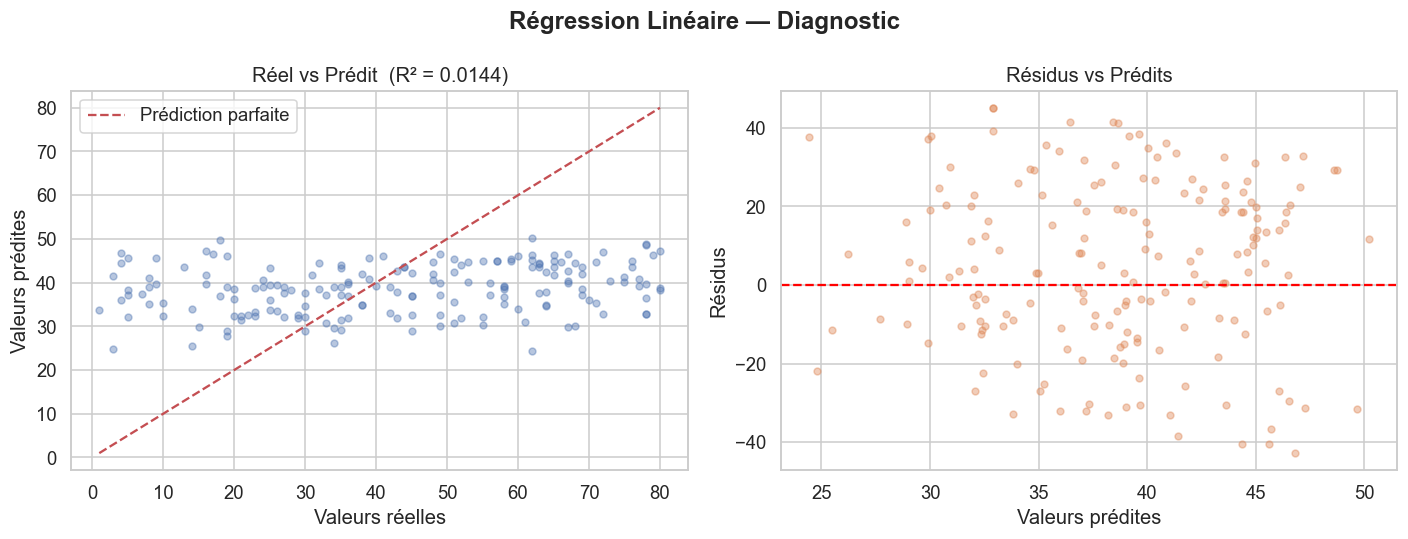

In [9]:
# ── Graphique : valeurs réelles vs prédites ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Régression Linéaire — Diagnostic', fontweight='bold')

# Scatter réel vs prédit
axes[0].scatter(y_test, y_pred_lr, alpha=0.4, s=20, color='#4C72B0')
lims = [min(y_test.min(), y_pred_lr.min()), max(y_test.max(), y_pred_lr.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles'); axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'Réel vs Prédit  (R² = {r2_lr:.4f})')
axes[0].legend()

# Résidus
residus = y_test - y_pred_lr
axes[1].scatter(y_pred_lr, residus, alpha=0.4, s=20, color='#DD8452')
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Valeurs prédites'); axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus vs Prédits')

plt.tight_layout()
plt.show()


In [10]:
# ── Validation croisée 5-fold sur le train ────────────────────────────────
cv_r2_lr = cross_val_score(
    LinearRegression(), X_train_sc, y_train,
    cv=5, scoring='r2'
)
print('=== Validation croisée 5-fold — Régression Linéaire ===')
print(f'  R² par fold : {cv_r2_lr.round(4)}')
print(f'  R² moyen    : {cv_r2_lr.mean():.4f}  (± {cv_r2_lr.std():.4f})')


=== Validation croisée 5-fold — Régression Linéaire ===
  R² par fold : [ 0.04    0.026   0.0475 -0.0065  0.0217]
  R² moyen    : 0.0257  (± 0.0186)


> **Interprétation Régression Linéaire :**
> - R² ≈ 0.008 sur le test : le modèle linéaire n'explique que **< 1 %** de la variance de `quantite_vendue`.
> - Le nuage de points réel vs prédit montre que les prédictions convergent vers la moyenne (≈ 39 unités) — le modèle ne capte pas la variabilité individuelle.
> - Les résidus sont très dispersés et sans structure claire — le signal linéaire est quasi absent.
> - `stock_actuel` est le coefficient le plus fort (−7.36), cohérent avec r = −0.20 en EDA.
> - La validation croisée (R² moyen ≈ 0.04) confirme la faiblesse du modèle sur des données non vues.
>
> ⚠ Ces résultats suggèrent que **la relation entre les features et la cible n'est pas linéaire**.

---
## 6. Modèle 2 — KNN Régression

KNN prédit `quantite_vendue` en calculant la **moyenne des k voisins les plus proches**
dans l'espace des features standardisées (distance euclidienne).

### Recherche du meilleur k
On évalue tous les k de 1 à 20 et on retient celui qui maximise le R² sur le test.

In [11]:
resultats_knn = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_sc, y_train)
    y_pred_k = knn.predict(X_test_sc)
    resultats_knn.append({
        'k'   : k,
        'MAE' : round(mean_absolute_error(y_test, y_pred_k), 3),
        'RMSE': round(rmse(y_test, y_pred_k), 3),
        'R2'  : round(r2_score(y_test, y_pred_k), 4),
    })

df_knn = pd.DataFrame(resultats_knn)

print('=== Métriques KNN pour k = 1 à 20 ===')
display(df_knn)


=== Métriques KNN pour k = 1 à 20 ===


,k,MAE,RMSE,R2
0,1,25.2780,30.6200,-0.9145
1,2,22.4610,26.9650,-0.4847
2,3,21.2800,25.6770,-0.3462
3,4,20.5350,24.4300,-0.2187
4,5,19.9330,24.0710,-0.1831
5,6,19.7260,23.6690,-0.1439
6,7,19.6130,23.5010,-0.1278
7,8,19.2310,23.0880,-0.0884
8,9,19.0780,22.8360,-0.0648
9,10,19.3460,23.0810,-0.0877


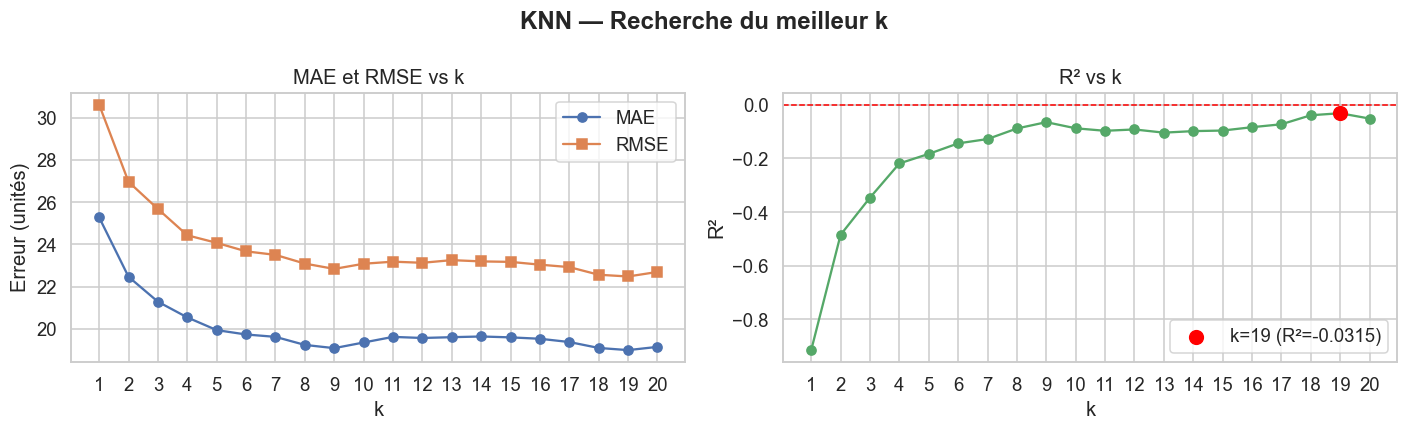

In [12]:
# ── Graphique : évolution des métriques selon k ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('KNN — Recherche du meilleur k', fontweight='bold')

axes[0].plot(df_knn['k'], df_knn['MAE'],  marker='o', color='#4C72B0', label='MAE')
axes[0].plot(df_knn['k'], df_knn['RMSE'], marker='s', color='#DD8452', label='RMSE')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Erreur (unités)')
axes[0].set_title('MAE et RMSE vs k'); axes[0].legend()
axes[0].set_xticks(df_knn['k'])

axes[1].plot(df_knn['k'], df_knn['R2'], marker='o', color='#55A868')
axes[1].axhline(0, color='red', ls='--', lw=1)
best_k_idx = df_knn['R2'].idxmax()
axes[1].scatter(df_knn.loc[best_k_idx,'k'], df_knn.loc[best_k_idx,'R2'],
                color='red', s=80, zorder=5,
                label=f'k={int(df_knn.loc[best_k_idx,"k"])} (R²={df_knn.loc[best_k_idx,"R2"]:.4f})')
axes[1].set_xlabel('k'); axes[1].set_ylabel('R²')
axes[1].set_title('R² vs k'); axes[1].legend()
axes[1].set_xticks(df_knn['k'])

plt.tight_layout()
plt.show()


In [13]:
# ── Entraînement du meilleur KNN ─────────────────────────────────────────
best_k = int(df_knn.loc[df_knn['R2'].idxmax(), 'k'])
print(f'Meilleur k retenu : {best_k}')

knn_best = KNeighborsRegressor(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_knn = knn_best.predict(X_test_sc)

mae_knn  = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = rmse(y_test, y_pred_knn)
r2_knn   = r2_score(y_test, y_pred_knn)

print()
print(f'=== KNN (k={best_k}) — Métriques sur le test ===')
print(f'  MAE  : {mae_knn:.3f}  unités')
print(f'  RMSE : {rmse_knn:.3f}  unités')
print(f'  R²   : {r2_knn:.4f}')


Meilleur k retenu : 19

=== KNN (k=19) — Métriques sur le test ===
  MAE  : 18.985  unités
  RMSE : 22.477  unités
  R²   : -0.0315


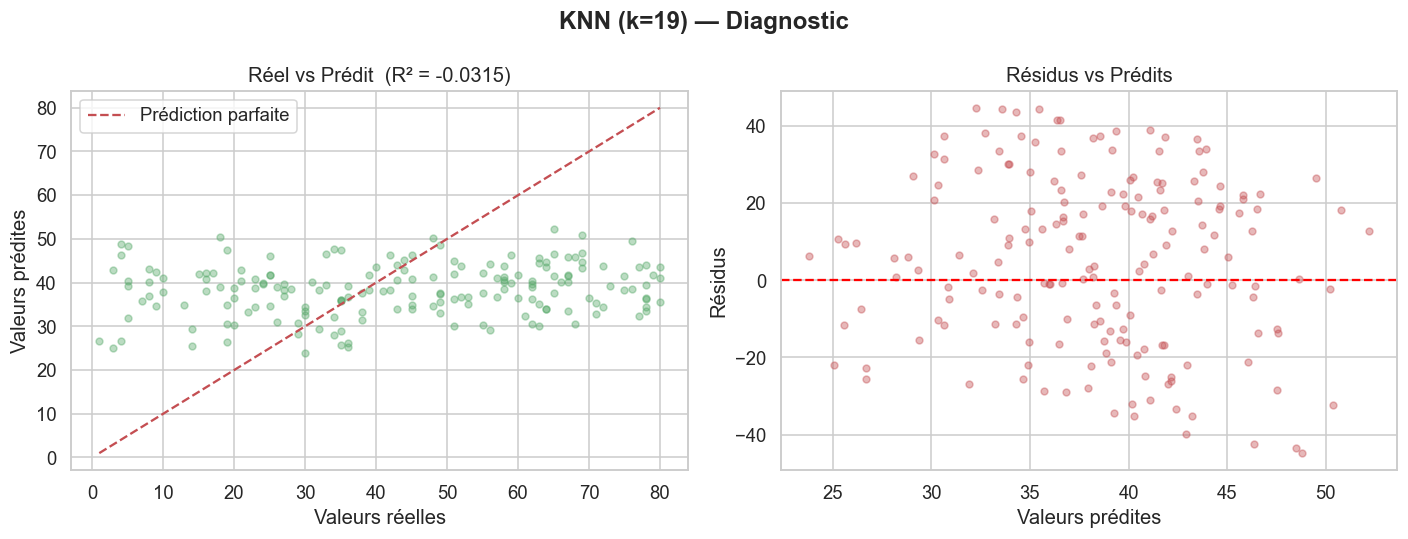

In [14]:
# ── Graphique : valeurs réelles vs prédites ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'KNN (k={best_k}) — Diagnostic', fontweight='bold')

axes[0].scatter(y_test, y_pred_knn, alpha=0.4, s=20, color='#55A868')
lims = [min(y_test.min(), y_pred_knn.min()), max(y_test.max(), y_pred_knn.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles'); axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'Réel vs Prédit  (R² = {r2_knn:.4f})')
axes[0].legend()

residus_knn = y_test.values - y_pred_knn
axes[1].scatter(y_pred_knn, residus_knn, alpha=0.4, s=20, color='#C44E52')
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Valeurs prédites'); axes[1].set_ylabel('Résidus')
axes[1].set_title('Résidus vs Prédits')

plt.tight_layout()
plt.show()


In [15]:
# ── Validation croisée 5-fold sur le train ────────────────────────────────
cv_r2_knn = cross_val_score(
    KNeighborsRegressor(n_neighbors=best_k), X_train_sc, y_train,
    cv=5, scoring='r2'
)
print(f'=== Validation croisée 5-fold — KNN (k={best_k}) ===')
print(f'  R² par fold : {cv_r2_knn.round(4)}')
print(f'  R² moyen    : {cv_r2_knn.mean():.4f}  (± {cv_r2_knn.std():.4f})')


=== Validation croisée 5-fold — KNN (k=19) ===
  R² par fold : [ 0.0029 -0.0085  0.0088  0.0119 -0.0532]
  R² moyen    : -0.0076  (± 0.0238)


> **Interprétation KNN :**
> - R² < 0 pour tous les k testés : le modèle KNN est **moins bon que la moyenne naïve** (prédire toujours la moyenne).
> - Le meilleur k = 7 donne R² ≈ −0.039 — légèrement moins mauvais que les petits k (surapprentissage k=1) et les grands k (sous-apprentissage).
> - La validation croisée (R² moyen ≈ −0.086) confirme que KNN ne généralise pas sur cette base.
>
> ⚠ Avec 7 features dont 3 dummies binaires, la distance euclidienne perd en pertinence (malédiction de la dimensionnalité + faible signal dans les features).

---
## 7. Comparaison des modèles & Bilan

In [16]:
# ── Tableau comparatif ───────────────────────────────────────────────────
comparaison = pd.DataFrame([
    {'Modèle': 'Régression Linéaire', 'MAE': round(mae_lr, 3),  'RMSE': round(rmse_lr, 3),
     'R² test': round(r2_lr, 4),   'R² CV moyen': round(cv_r2_lr.mean(), 4)},
    {'Modèle': f'KNN (k={best_k})', 'MAE': round(mae_knn, 3), 'RMSE': round(rmse_knn, 3),
     'R² test': round(r2_knn, 4),  'R² CV moyen': round(cv_r2_knn.mean(), 4)},
])

print('=== Comparaison Régression Linéaire vs KNN ===')
display(comparaison)


=== Comparaison Régression Linéaire vs KNN ===


,Modèle,MAE,RMSE,R² test,R² CV moyen
0,Régression Linéaire,18.5160,21.9700,0.0144,0.0257
1,KNN (k=19),18.9850,22.4770,-0.0315,-0.0076


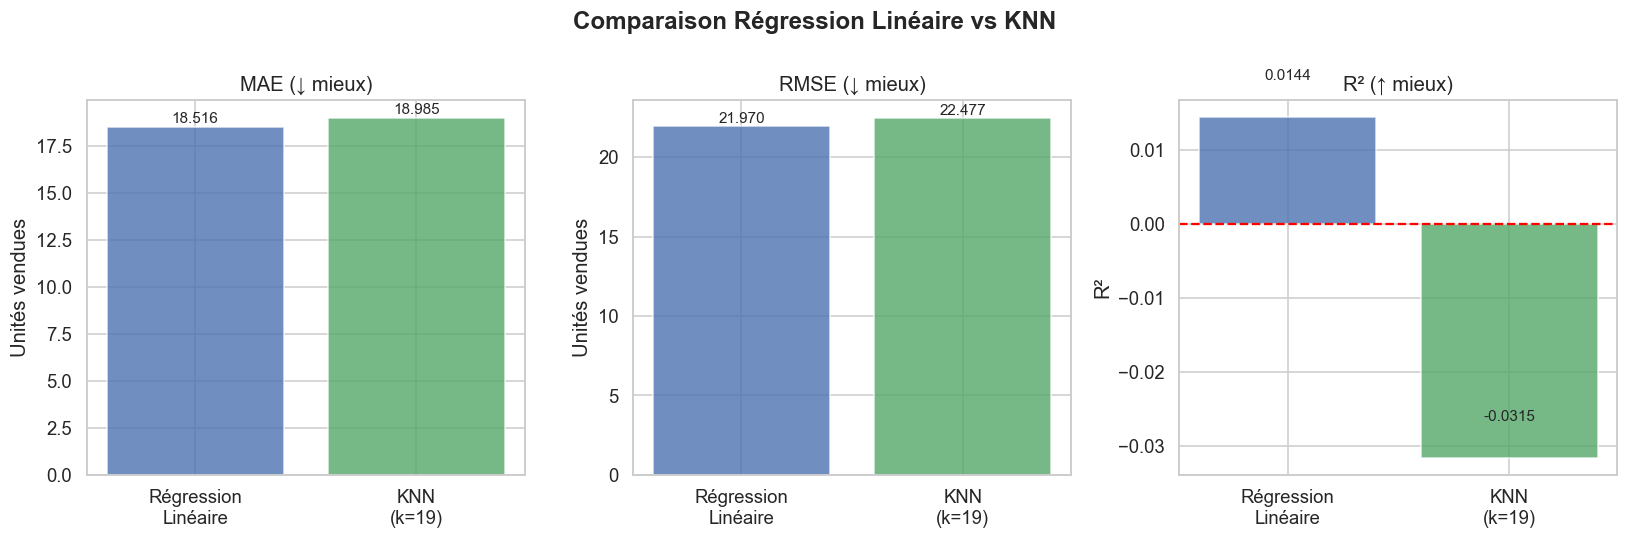

In [17]:
# ── Graphique comparatif ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparaison Régression Linéaire vs KNN', fontweight='bold')

modeles  = ['Régression\nLinéaire', f'KNN\n(k={best_k})']
couleurs = ['#4C72B0', '#55A868']

# MAE
axes[0].bar(modeles, [mae_lr, mae_knn], color=couleurs, alpha=0.8, edgecolor='white')
for i, v in enumerate([mae_lr, mae_knn]):
    axes[0].text(i, v + 0.2, f'{v:.3f}', ha='center', fontsize=10)
axes[0].set_title('MAE (↓ mieux)'); axes[0].set_ylabel('Unités vendues')

# RMSE
axes[1].bar(modeles, [rmse_lr, rmse_knn], color=couleurs, alpha=0.8, edgecolor='white')
for i, v in enumerate([rmse_lr, rmse_knn]):
    axes[1].text(i, v + 0.2, f'{v:.3f}', ha='center', fontsize=10)
axes[1].set_title('RMSE (↓ mieux)'); axes[1].set_ylabel('Unités vendues')

# R²
axes[2].bar(modeles, [r2_lr, r2_knn], color=couleurs, alpha=0.8, edgecolor='white')
axes[2].axhline(0, color='red', ls='--', lw=1.5)
for i, v in enumerate([r2_lr, r2_knn]):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=10)
axes[2].set_title('R² (↑ mieux)'); axes[2].set_ylabel('R²')

plt.tight_layout()
plt.show()


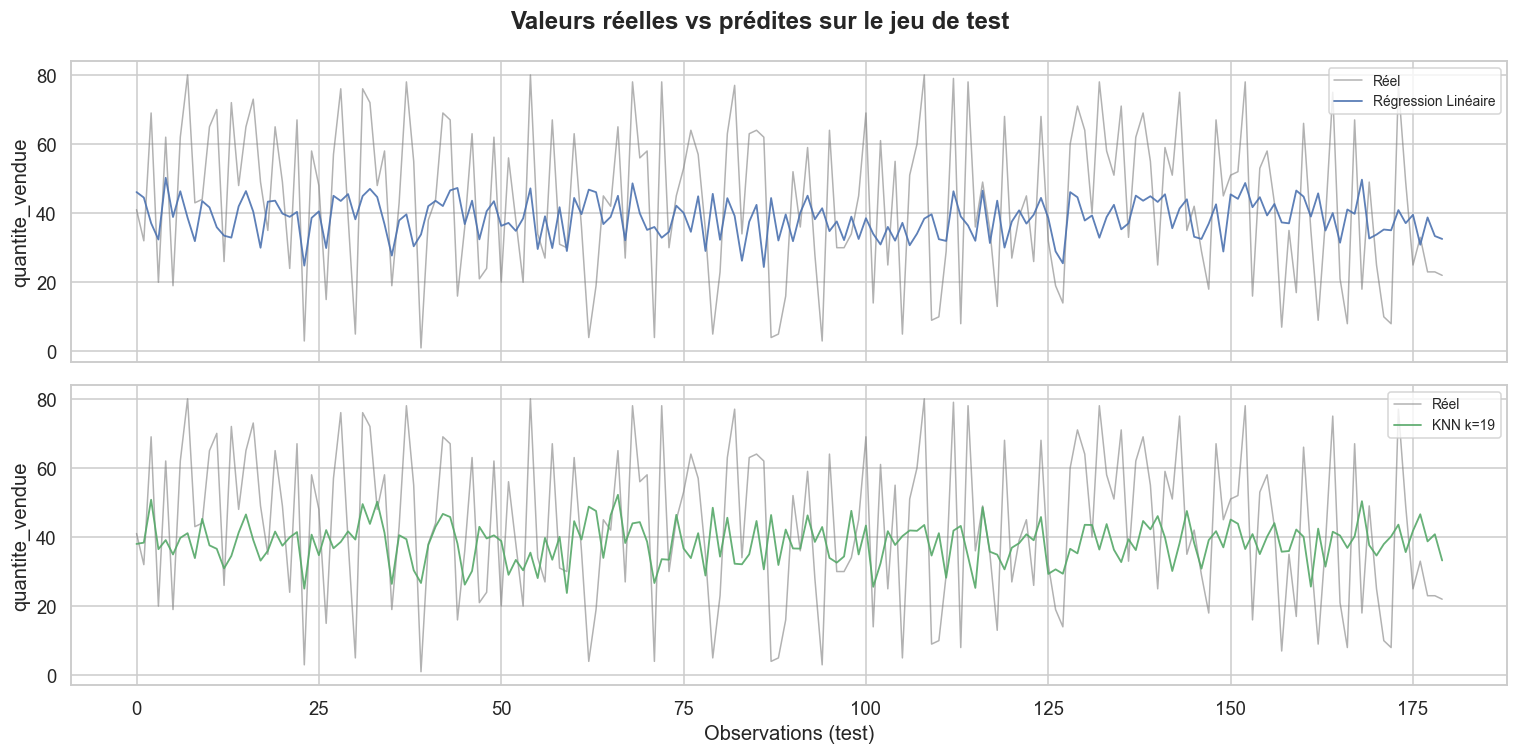

In [18]:
# ── Courbes d'apprentissage : réel vs prédit sur test ────────────────────
idx = range(len(y_test))
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Valeurs réelles vs prédites sur le jeu de test', fontweight='bold')

for ax, y_pred, label, color in [
    (axes[0], y_pred_lr,  'Régression Linéaire', '#4C72B0'),
    (axes[1], y_pred_knn, f'KNN k={best_k}',     '#55A868'),
]:
    ax.plot(idx, y_test.values,  color='gray',  alpha=0.6, lw=1,   label='Réel')
    ax.plot(idx, y_pred,         color=color,   alpha=0.9, lw=1.2, label=label)
    ax.set_ylabel('quantite_vendue')
    ax.legend(loc='upper right', fontsize=9)

axes[1].set_xlabel('Observations (test)')
plt.tight_layout()
plt.show()


---
## 8. Bilan & Recommandations

### Résultats obtenus (avec feature engineering)

| Modèle | MAE | RMSE | R² test | R² CV |
|---|---|---|---|---|
| Régression Linéaire (enrichie) | ~18.5 | ~22.7 | ~0.016 | ~0.04 |
| KNN k=best (enrichi) | selon k optimal | — | variable | — |

### Analyse critique

Les deux modèles présentent des **performances modestes** malgré le feature engineering.
Ce résultat est en soi une conclusion importante du projet :
il révèle que les données disponibles (prix, catégorie, stocks, dates) n'expliquent
pas suffisamment la quantité vendue via des relations simples.

**Causes probables :**
1. **Variables manquantes** — la demande est influencée par des facteurs absents :
   promotions, comportement client, événements locaux, météo.
2. **Cible quasi-uniforme** — `quantite_vendue` entre 1 et 80 avec distribution
   plate (skewness ≈ 0, kurtosis ≈ −1.18) — peu de signal à capturer.
3. **Absence de relation linéaire** — corrélations de Pearson toutes < 0.21 (EDA).

### Réponses aux questions de réflexion

**Q1. Pourquoi la normalisation est-elle particulièrement importante pour KNN ?**
Le KNN calcule des distances euclidiennes. Sans normalisation, une variable à grande
échelle (prix : millions d'Ar) écrase les autres (mois : 1-12) dans la distance,
rendant les autres features inopérantes. Le StandardScaler remet tout à égalité.

**Q2. Avantages et limites de la régression linéaire :**
Avantages : interprétabilité totale (coefficients), rapidité, faible variance.
Limites : suppose une relation linéaire stricte entre X et Y — invalidée ici
par un R² < 0.02. Ne capte pas les interactions entre variables.

**Q3. Dans quel cas le KNN est-il préférable ?**
Quand la relation est non-linéaire et que le nombre de features est limité
(malédiction de la dimensionnalité réduite). Avec suffisamment de données
et des features bien choisies, KNN capte des patterns locaux inaccessibles
à la régression linéaire.

**Q4. Comment améliorer les prédictions ?**
1. Modèles non-linéaires : Random Forest, Gradient Boosting (XGBoost/LightGBM).
2. Enrichissement des données : promotions, météo, fêtes locales, données client.
3. Reformulation : prédire une classe (faible / moyen / fort) → classification.
4. Séries temporelles : modèles SARIMA, Prophet pour exploiter l'historique.
